# SHAP Values for Model Explainability with `shapviz`

## Overview

SHAP (SHapley Additive exPlanations) is a game-theoretic framework for explaining any machine learning model's predictions. A SHAP value for feature j on observation i represents the contribution of feature j to the prediction for observation i, averaged over all possible feature subsets.

**Key properties:**
- **Local:** Explains individual predictions, not just global averages
- **Consistent:** If model A relies more on feature X than model B, SHAP values for X will be higher in A
- **Additive:** Σ SHAP values = prediction − expected prediction
- **Model-agnostic:** Works with any model (though tree SHAP is exact and fast for XGBoost/LightGBM/ranger)

**SHAP value types:**

| Type | What it shows |
|---|---|
| **Mean |SHAP|** | Global feature importance — how much each feature contributes on average |
| **Beeswarm plot** | Distribution of SHAP values across all observations; shows direction and spread |
| **Dependence plot** | SHAP value vs. feature value; shows marginal effect + interaction with a second feature |
| **Waterfall plot** | Local: how each feature drove a specific prediction away from the baseline |
| **Force plot** | Local: compact visual of positive/negative contributions per observation |

---

## Setup

In [3]:
library(tidyverse)
library(ggplot2)
library(xgboost)
library(shapviz)
library(patchwork)

set.seed(42)

# ── Dataset ───────────────────────────────────────────────────────────────────
n <- 600
shap_data <- tibble(
  nitrate     = rnorm(n, 3, 1.2),
  water_qual  = rnorm(n, 6, 1.5),
  distance_km = rexp(n, 0.4),
  elevation   = rnorm(n, 200, 80),
  slope_pct   = abs(rnorm(n, 10, 5)),
  habitat_ref = as.integer(runif(n) < 0.35),
  habitat_deg = as.integer(runif(n) < 0.30),
  log_odds    = -1 + 0.7 * water_qual - 0.8 * nitrate - 0.25 * distance_km +
                0.9 * habitat_ref - 1.0 * habitat_deg,
  label       = rbinom(n, 1, plogis(log_odds))
)

feature_cols <- c("nitrate", "water_qual", "distance_km", "elevation",
                  "slope_pct", "habitat_ref", "habitat_deg")

train_idx  <- sample(n, 450)
X_train    <- as.matrix(shap_data[train_idx,  feature_cols])
X_explain  <- as.matrix(shap_data[-train_idx, feature_cols])
y_train    <- shap_data$label[train_idx]

dtrain <- xgb.DMatrix(X_train, label = y_train)

# ── Fit XGBoost ───────────────────────────────────────────────────────────────
# Use xgb.train() with DMatrix — xgboost() expects raw matrix + separate y
xgb_fit <- xgb.train(
  data    = dtrain,
  params  = list(
    objective        = "binary:logistic",
    eta              = 0.05,
    max_depth        = 4,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = "auc",
    seed             = 42      # seed goes in params, not top level
  ),
  nrounds = 200,
  verbose = 0
)

---

## Compute SHAP Values

In [4]:
# shapviz builds the SHAP object from the XGBoost model + data to explain
# XGBoost computes exact tree SHAP values efficiently
shap_obj <- shapviz::shapviz(xgb_fit, X_pred=X_explain)

cat("SHAP object structure:\n")
print(shap_obj)
# shap_obj$S: SHAP value matrix (n_observations × n_features)
# shap_obj$X: feature value matrix
# baseline: E[f(x)] — the expected prediction (the reference for all SHAP values)

# Check: for any observation, sum of SHAP values + baseline = raw prediction
obs_1_shap  <- colSums(shap_obj$S[1,,drop=FALSE])
obs_1_pred  <- predict(xgb_fit, X_explain[1,,drop=FALSE], outputmargin=TRUE)
cat(sprintf("\nObs 1: SHAP sum + baseline = %.4f; raw prediction = %.4f\n",
            sum(obs_1_shap) + attr(shap_obj, "baseline"),
            obs_1_pred))

SHAP object structure:
'shapviz' object representing 150 x 7 SHAP matrix. Top lines:

        nitrate water_qual distance_km  elevation    slope_pct habitat_ref
[1,] -0.6347051   1.403719   0.6136040 -0.1836662 -0.008253098  -0.2558765
[2,] -0.6387584   1.824728   0.5951231  0.5966452 -0.116469249  -0.3321448
     habitat_deg
[1,]   0.2161087
[2,]   0.2623814


---

## Global Importance: Beeswarm and Bar Plot

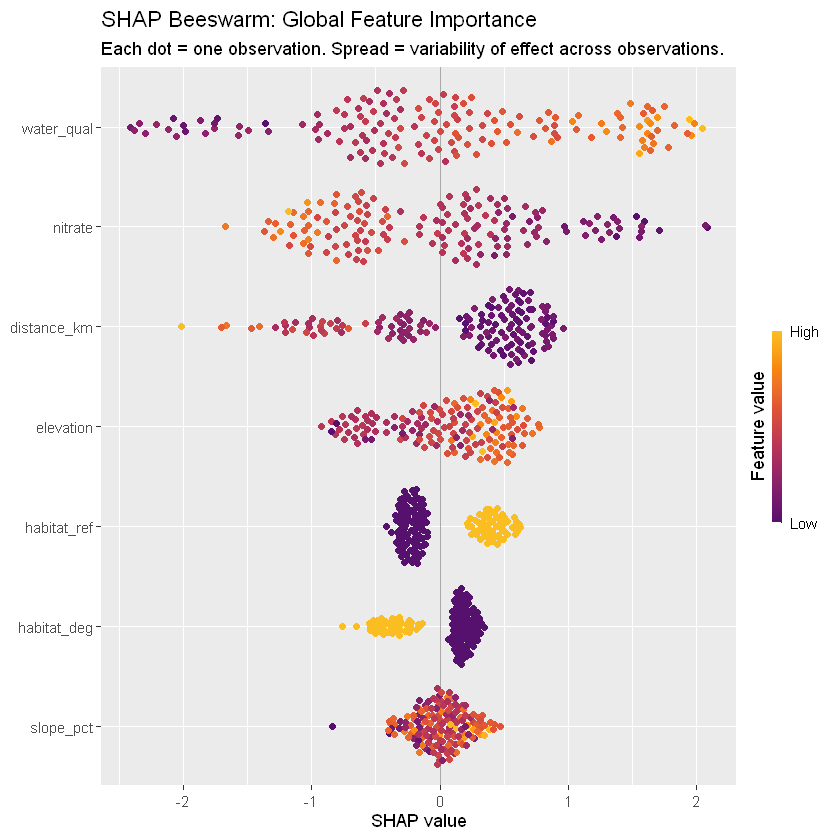

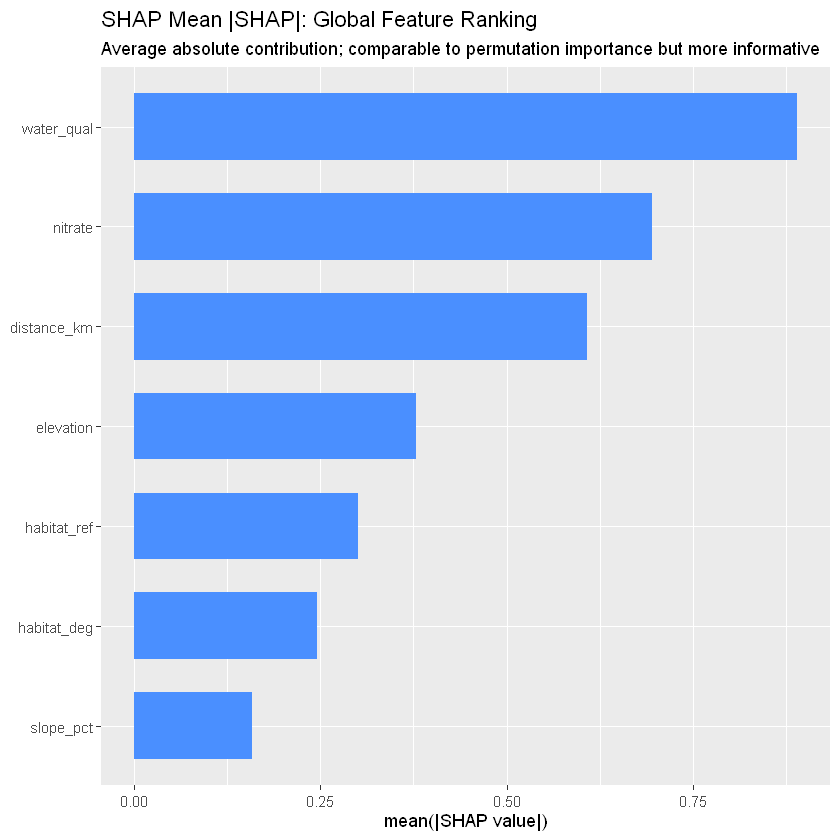

In [5]:
# ── Beeswarm plot (aka SHAP summary plot) ────────────────────────────────────
# Each dot = one observation
# x-axis: SHAP value (positive = pushed toward presence; negative = absence)
# Color: feature value (red = high; blue = low)
shapviz::sv_importance(
  shap_obj,
  kind   = "beeswarm",   # "bar" for mean|SHAP|; "beeswarm" for full distribution
  max_display = 7
) +
  labs(title="SHAP Beeswarm: Global Feature Importance",
       subtitle="Each dot = one observation. Spread = variability of effect across observations.")

# ── Bar plot: mean |SHAP| ─────────────────────────────────────────────────────
shapviz::sv_importance(
  shap_obj,
  kind       = "bar",
  max_display = 7,
  fill       = "#4a8fff"
) +
  labs(title="SHAP Mean |SHAP|: Global Feature Ranking",
       subtitle="Average absolute contribution; comparable to permutation importance but more informative")

---

## Dependence Plots: How Features Drive Predictions

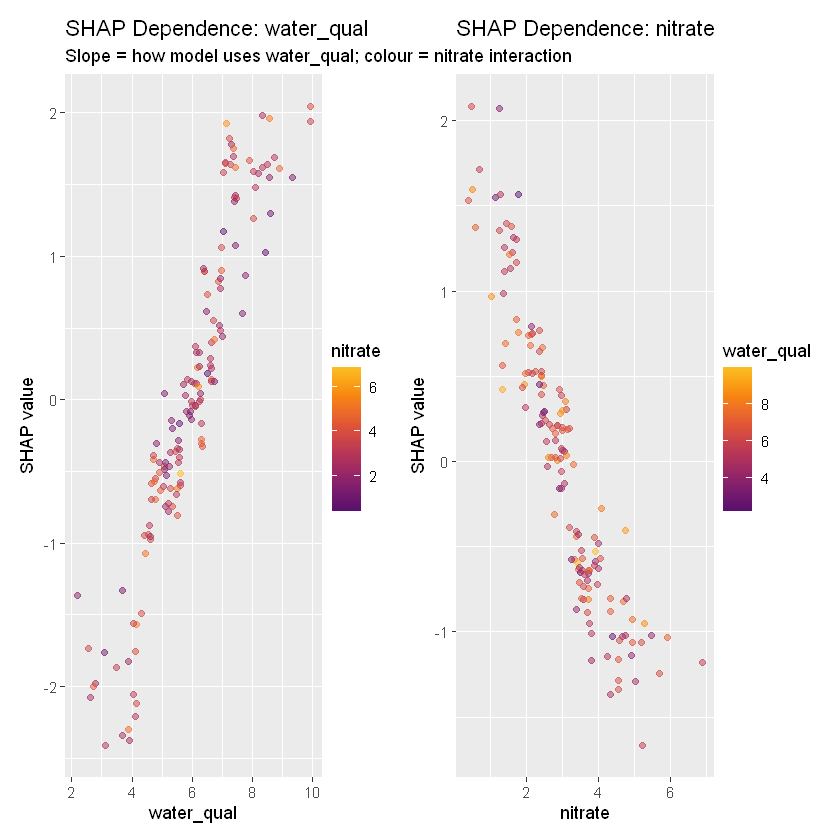

In [6]:
# SHAP dependence plot: SHAP value vs. feature value
# Shape of the relationship = how the model uses this feature
# Color by a second feature: reveals interactions

p1 <- shapviz::sv_dependence(
  shap_obj,
  v          = "water_qual",    # primary feature on x-axis
  color_var  = "nitrate",       # interaction feature
  alpha      = 0.5
) +
  labs(title="SHAP Dependence: water_qual",
       subtitle="Slope = how model uses water_qual; colour = nitrate interaction")

p2 <- shapviz::sv_dependence(
  shap_obj,
  v         = "nitrate",
  color_var = "water_qual",
  alpha     = 0.5
) +
  labs(title="SHAP Dependence: nitrate")

(p1 | p2)

---

## Local Explanations: Waterfall and Force Plots

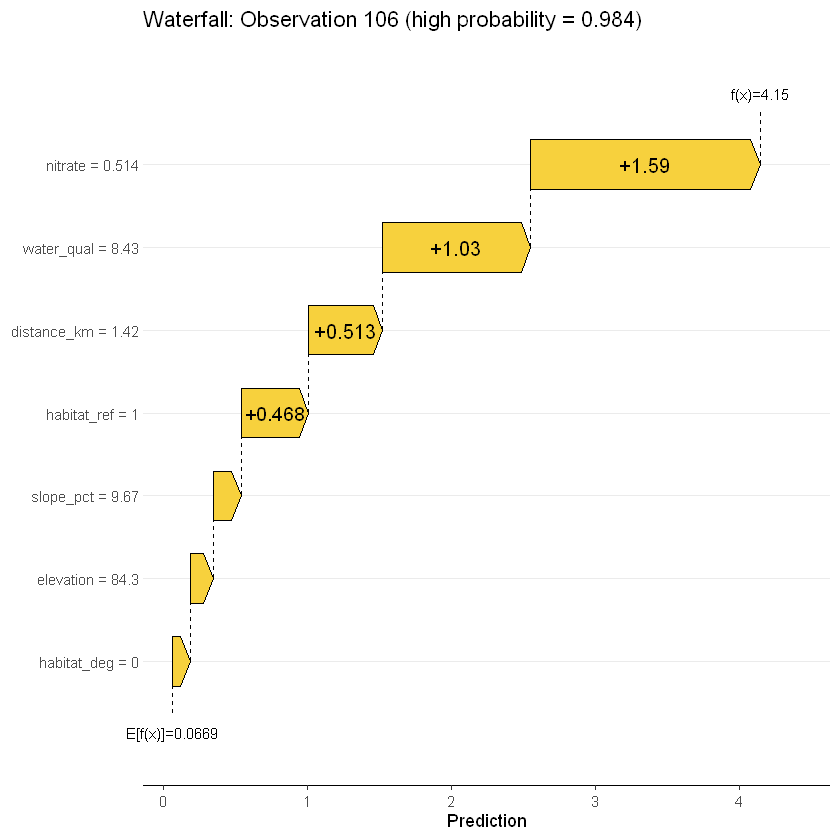

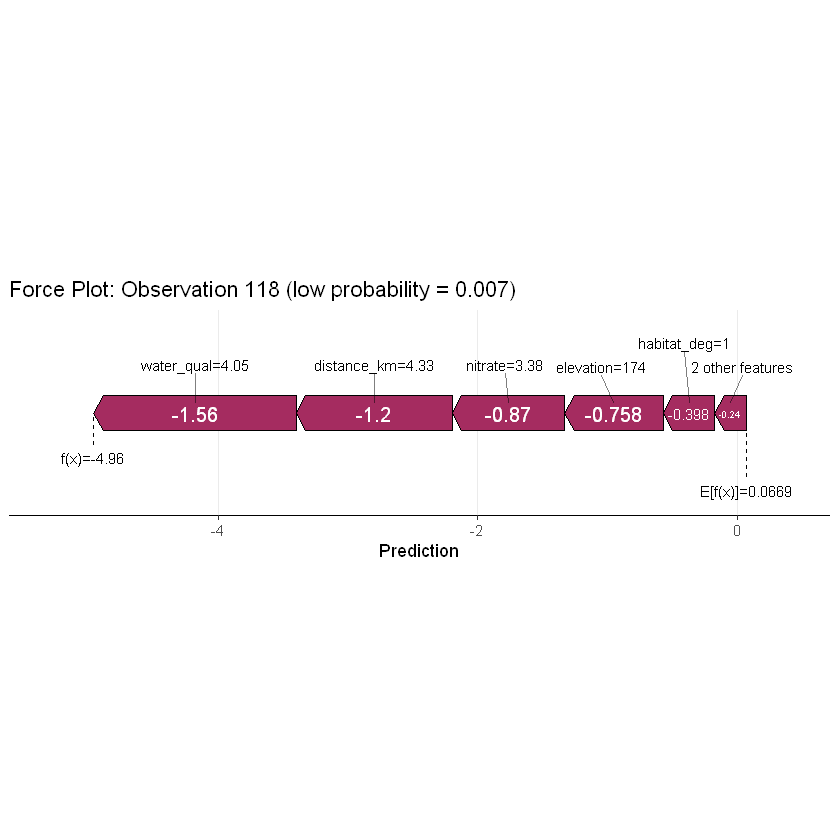

In [7]:
# Select two contrasting observations to explain
test_probs <- predict(xgb_fit, X_explain)
obs_high   <- which.max(test_probs)   # most confidently predicted present
obs_low    <- which.min(test_probs)   # most confidently predicted absent

# ── Waterfall plot for obs_high ───────────────────────────────────────────────
# Shows how each feature pushed the prediction away from the baseline
shapviz::sv_waterfall(shap_obj, row_id=obs_high) +
  labs(title=sprintf("Waterfall: Observation %d (high probability = %.3f)",
                     obs_high, test_probs[obs_high]))

# ── Force plot for obs_low ────────────────────────────────────────────────────
# Compact horizontal version of the waterfall
shapviz::sv_force(shap_obj, row_id=obs_low) +
  labs(title=sprintf("Force Plot: Observation %d (low probability = %.3f)",
                     obs_low, test_probs[obs_low]))

---

## Common Pitfalls

**1. Using gain-based feature importance instead of SHAP for final reporting**  
Gain importance (the default in XGBoost and LightGBM) is biased toward features with many split points. SHAP values are theoretically grounded and consistent. Always use mean |SHAP| as the primary importance measure.

**2. Confusing SHAP values with the feature effect in the original space**  
SHAP values for `binary:logistic` are on the log-odds scale (the raw model output), not the probability scale. A SHAP value of +1 does not mean "1 unit increase in probability." Use `predict(xgb_fit, type='response')` for probabilities, but note that SHAP values for probability outputs are not additive — always use log-odds SHAP for decomposition.

**3. Computing SHAP values on the training set**  
SHAP values computed on the training set reflect training fit, not generalisation. Always compute SHAP values on a held-out test or validation set for reporting.

**4. Treating SHAP as a causal explanation**  
SHAP values quantify how much each feature contributes to a model's prediction — they explain the model, not the data-generating process. A high SHAP value for nitrate means the model uses nitrate heavily, not that nitrate causally determines presence. Causal claims require causal designs.

**5. Using kernel SHAP when tree SHAP is available**  
Kernel SHAP is a model-agnostic approximation and is computationally expensive (O(2^p) or slow Monte Carlo). Tree SHAP is exact and very fast for XGBoost, LightGBM, and ranger. Always use tree SHAP for tree-based models via `shapviz(model, X_pred=X)`.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*